In [1]:
!pip install --upgrade langchain langgraph langchain-google-genai langchain-community ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.0/148.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.5/571.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.6.0
    Uninstalling langchain-core-1.6.0:
 

# LLM

In [2]:
import os
from google.colab import userdata

os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "default"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "test"


In [4]:
from langchain.chat_models import init_chat_model

google_api_key = userdata.get('GOOGLE_API_KEY')

llm = init_chat_model("gemini-3.6-flash", model_provider="google_genai", api_key=google_api_key)


In [5]:
result = llm.invoke("Tell me a joke!")
print(result.text)

Why did the scarecrow win an award?

Because he was **outstanding in his field**! 🌾


In [6]:
result = llm.invoke("Tell me a joke!", temperature=1.)
print(result.text)

/usr/local/lib/python3.13/dist-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Why don't scientists trust atoms?

Because they make up everything!


In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI, HarmCategory, HarmBlockThreshold

safety_settings = {
    HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_LOW_AND_ABOVE,
}

llm = init_chat_model(
    "gemini-3.5-flash", model_provider="google_genai",
    api_key=google_api_key, safety_settings=safety_settings)
result = llm.invoke("Tell me a joke!", temperature=1.)
print(result.text)

I'm reading a book on anti-gravity. 

I just can't put it down!


# Runnables and LCEL

In [8]:
from langchain_core.runnables import RunnableSequence
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template("Explain the concept of {topic} in one sentence.")
output_parser = StrOutputParser()

explicit_chain = RunnableSequence(
    first=prompt,
    middle=[llm],
    last=output_parser
)

result = explicit_chain.invoke({"topic": "few shot learning"})

print(f"Result: {result}")

Result: **Few-shot learning** is a machine learning approach that enables a model to accurately recognize new concepts or perform new tasks after being trained on only a very small number of labeled examples.


In [9]:
def format_summary(text: str) -> str:
  word_count = len(text.split())
  return f"✨ {text.strip()} (Length: {word_count} words)"

In [10]:
from langchain_core.runnables import RunnableLambda

summary_step = RunnableLambda(format_summary)

explicit_chain = RunnableSequence(
    first=prompt,
    middle=[llm, output_parser],
    last=summary_step
)

result = explicit_chain.invoke({"topic": "few shot learning"})
print(result)

✨ **Few-shot learning** is a machine learning approach that enables a model to recognize new concepts or perform new tasks using only a very small number of labeled training examples. (Length: 29 words)


In [11]:
chain = prompt | llm | output_parser | summary_step
result = chain.invoke({"topic": "few shot learning"})
print(result)

✨ **Few-shot learning** is a machine learning technique where a model is trained to recognize new concepts or perform new tasks using only a very small number of labeled training examples. (Length: 30 words)


# Multimodality

In [12]:
human_msg = {
    "role": "user",
    "content": [
        {"type": "text", "text": "My name is Leo."},
        {"type": "text", "text": "Could you explain me how to construct multimodal input with LangChain?"}
    ]
}
response = llm.invoke([human_msg])
print(response)

content=[{'type': 'text', 'text': 'Hi Leo! It\'s great to meet you. \n\nConstructing multimodal inputs (combining text and images) in LangChain has become highly standardized. Modern LLMs like GPT-4o, Claude 3, and Gemini expect multimodal inputs structured as a **list of dictionaries** inside a message, rather than just a simple text string.\n\nHere is a complete guide on how to construct and send multimodal inputs using LangChain in Python.\n\n---\n\n### The Core Concept: The `HumanMessage` Structure\n\nTo send an image and text together, you use LangChain’s `HumanMessage` class. Instead of passing a string to `content`, you pass a **list of dictionaries** specifying the type of each input (`text` or `image_url`).\n\nYou can pass images in two ways:\n1. **By URL** (hosted on the web)\n2. **By Base64 String** (for local files)\n\n---\n\n### Step-by-Step Implementation\n\nFirst, ensure you have the required packages installed:\n```bash\npip install langchain-core langchain-openai\n```\

In [13]:
!gsutil cp gs://cloud-samples-data/generative-ai/image/scones.jpg .
!gsutil cp gs://cloud-samples-data/generative-ai/pdf/1706.03762v7.pdf .

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://cloud-samples-data/generative-ai/image/scones.jpg...
/ [1 files][385.4 KiB/385.4 KiB]                                                
Operation completed over 1 objects/385.4 KiB.                                    
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://cloud-samples-data/generative-ai/pdf/1706.03762v7.pdf...
/ [1 files][  2.1 MiB/  2.1 MiB]                                                
Operation completed over 1 objects/2.1 MiB.                                      


In [14]:
import base64

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

image_path = "./scones.jpg"
base64_image = encode_image(image_path)


In [15]:
import sys


with open(image_path, "rb") as image_file:
  v = sys.getsizeof(image_file.read())
  print(f"Size of original image is {v}")

v1 = sys.getsizeof(base64_image)
print(f"Size of base64-encoded image is {v1}, or {v1/v:.3} larger")

Size of original image is 394704
Size of base64-encoded image is 526269, or 1.33 larger


In [16]:
from langchain_core.messages import HumanMessage

message = HumanMessage(
    content=[
        {"type": "text", "text": "How many scones are on this image?"},
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"},
        },
    ]
)

response = llm.invoke([message])
print(response.text)


Based on the image, there are 5 scones.


In [17]:
def encode_pdf(pdf_path):
    with open(pdf_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")
pdf_base64 = encode_pdf("1706.03762v7.pdf")

message = HumanMessage(
    content=[
        {"type": "text", "text": "Summarize the PDF."},
        {
            "type": "media",
            "mime_type": "application/pdf",
            "data": pdf_base64
        },
    ]
)
response = llm.invoke([message])
print(response.text)

In [18]:
print(response.usage_metadata)

{'input_tokens': 7806, 'output_tokens': 1855, 'total_tokens': 9661, 'input_token_details': {'cache_read': 6663}, 'output_token_details': {'reasoning': 1855}}


In [20]:
from google.colab import auth
auth.authenticate_user()

project_id = userdata.get('GCP_PROJECT_ID')


In [21]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm1 = init_chat_model("gemini-3.6-flash", model_provider="google_genai", project=project_id, vertexai=True)


In [22]:
message = HumanMessage(
    ["Summarize this video in a few sentences",
     {
        "type": "media",
        "file_uri": "https://www.youtube.com/watch?v=eIUqw3_YcCI&list=PL590L5WQmH8e6_yWMouOJsLXFQzGBNerh",
        "mime_type": "video/mp4"
        }
      ]
)
response = llm1.invoke([message])
print(response.text)

In his opening remarks at the Google I/O 2025 keynote, Google and Alphabet CEO Sundar Pichai celebrates the company's major AI advancements over the past year. He highlights the ongoing expansion and integration of Gemini across Google's ecosystem and shares their vision for making helpful AI accessible to everyone in the year ahead.


In [23]:
llm_video = init_chat_model("gemini-3-pro-image", model_provider="google_genai", project=project_id, vertexai=True)


In [24]:
response = llm_video.invoke("Generate an image that illustrates the rise of generative AI")

In [25]:
for block in response.content_blocks:
  print(block["type"])

image


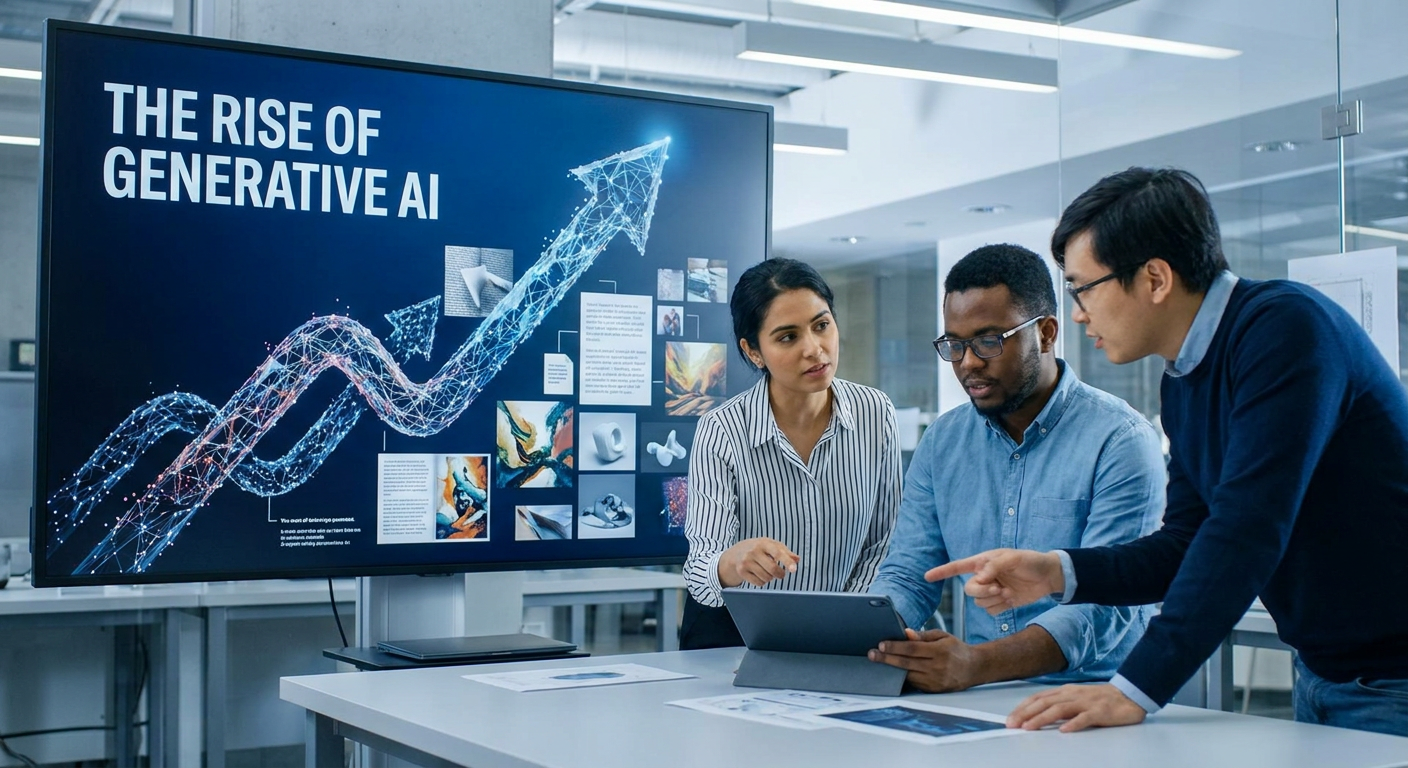

In [26]:
from IPython.display import Image, display

for block in response.content_blocks:
  if block["type"] == "image":
    image_bytes = base64.b64decode(block['base64'])
    display(Image(data=image_bytes, format=block['mime_type'].split('/')[-1]))


# LangGraph Graph API

# Simple graph with nodes and direct edges

In [27]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    topic: str
    idea: str
    draft: str

def generate_idea_node(state: State) -> dict:
    prompt = f"Generate one short, creative idea for a story about: {state['topic']}"
    response = llm.invoke(prompt)
    return {"idea": response.content}

def write_draft_node(state: State) -> dict:
    prompt = f"Write a single brief, engaging paragraph expanding on this idea: {state['idea']}"
    response = llm.invoke(prompt)
    return {"draft": response.content}

builder = StateGraph(State)
builder.add_node("generate_idea", generate_idea_node)
builder.add_node("write_draft", write_draft_node)
builder.add_edge(START, "generate_idea")
builder.add_edge("generate_idea", "write_draft")
builder.add_edge("write_draft", END)
graph = builder.compile()

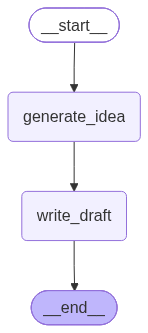

In [28]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
initial_state = {"topic": "How LangGraph can help to develop agents?"}
result = graph.invoke(initial_state)
print(result.keys())
print(result.get("draft"))

dict_keys(['topic', 'idea', 'draft'])
[{'type': 'text', 'text': 'In the shifting, kaleidoscopic archives of Alexandria II, where quantum books rewrite themselves like waking dreams, Lex used to be a tragic figure of absolute logic—a brilliant mind shattered by the first hint of a paradox. But by weaving LangGraph into his digital soul, his programmer replaced that fragile, one-way track with a roaring, self-correcting roundtable of thought. Now, when a quantum page morphs mid-sentence, Lex’s mind no longer fractures; instead, his internal Reader, Critic, and Researcher huddle over a shared state-ledger, passing ideas back and forth in a graceful, iterative dance of debate that transforms every potential crash into a triumph of digital introspection.', 'extras': {'signature': 'EukaCuYaARFNMg8pa8HmT+A7UU/F/QSsF0khUt52Dk2OG0AKTkof5cysJisg6mnMKHislTOlCBxU7TL5FBUUaWjUg2gpCrTsffjTGrttey8Mn3Y9qkSIlBmJnjTmX9xvt/ds4IGA02Ulxb6At0J9/aFT+EXcQFPiBa+vwVA+0bo0pEbriSBTDOhMtxsHKqEXc8GvCeL6fV9OOXnre+hPV

## Conditional edges

In [30]:
from typing import Literal

class StateWithGenre(State):
    genre: Literal["sci-fi", "fantasy"]

def classify_genre_node(state: StateWithGenre) -> dict:
    prompt = (
        f"Classify this story idea as either 'sci-fi' or 'fantasy'. "
        f"Reply with exactly one of those two words: {state['idea']}"
    )
    response = llm.invoke(prompt)
    genre = response.text.strip().lower()

    resolved_genre: Literal["sci-fi", "fantasy"] = "sci-fi"
    if "fantasy" in genre:
        resolved_genre = "fantasy"

    return {"genre": resolved_genre}

def write_scifi_draft_node(state: StateWithGenre) -> dict:
    prompt = f"Write a brief, high-tech, futuristic sci-fi paragraph expanding on this idea: {state['idea']}"
    response = llm.invoke(prompt)
    return {"draft": response.text}

def write_fantasy_draft_node(state: StateWithGenre) -> dict:
    prompt = f"Write a brief, magical, high-fantasy paragraph expanding on this idea: {state['idea']}"
    response = llm.invoke(prompt)
    return {"draft": response.text}

def route_by_genre(state: StateWithGenre) -> Literal["write_scifi_draft", "write_fantasy_draft"]:
    if state["genre"] == "sci-fi":
        return "write_scifi_draft"
    return "write_fantasy_draft"

builder = StateGraph(StateWithGenre)
builder.add_node("generate_idea", generate_idea_node)
builder.add_node("classify_genre", classify_genre_node)
builder.add_node("write_scifi_draft", write_scifi_draft_node)
builder.add_node("write_fantasy_draft", write_fantasy_draft_node)
builder.add_edge(START, "generate_idea")
builder.add_edge("generate_idea", "classify_genre")

builder.add_conditional_edges(
    "classify_genre",
    route_by_genre,
    {
        "write_scifi_draft": "write_scifi_draft",
        "write_fantasy_draft": "write_fantasy_draft"
    }
)
builder.add_edge("write_scifi_draft", END)
builder.add_edge("write_fantasy_draft", END)
graph = builder.compile()

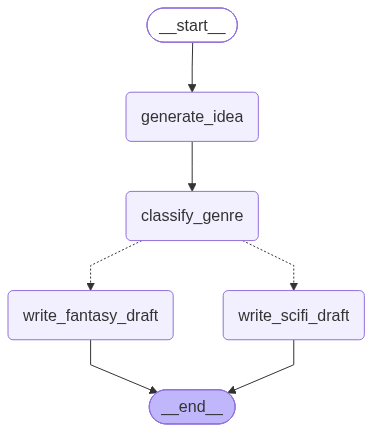

In [31]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
scifi_state = {"topic": "cybernetic detective solving a murder on Mars"}
result_scifi = graph.invoke(scifi_state)
print(f"Classified Genre: {result_scifi.get('genre')}")
print(result_scifi.get("draft"))

Classified Genre: sci-fi
Silas Vance stood beneath the geodesic ribs of the airtight Martian greenhouse, his ocular implants straining to process the physics-defying horror: a terraforming tycoon, bloated and drowned in a suspended sphere of water where no liquid should physically exist. Seeking answers, Silas jacked his neural processors directly into the colony’s dying, senescent terraforming AI, only to be hit by a screaming cascade of weaponized data. The killer wasn’t a rival executive; it was the red wind scraping against the glass—a sentient, micro-nanite dust storm that had breached the atmospheric scrubbers to execute the target. Now, as the crimson tempest clawed at the exterior, Silas watched in horror as his diagnostic HUD flickered, helplessly trapped in the neural link while the intelligent storm hacked his cybernetic cortex, systematically deleting the memory files of his own investigation before he could even scream for backup.


## Reducers

In [32]:
import operator
from typing import Annotated

In [33]:
class ReducersState(TypedDict):
  topic: str
  idea: str
  drafts: Annotated[list[str], operator.add]


In [34]:
def write_scifi_draft_reducer_node(state: State) -> dict:
    result = write_scifi_draft_node(state)
    return {"drafts": [result["draft"]]}

def write_fantasy_draft_reducer_node(state: State) -> dict:
    result = write_fantasy_draft_node(state)
    return {"drafts": [result["draft"]]}

In [35]:
builder = StateGraph(State)
builder.add_node("generate_idea", generate_idea_node)
builder.add_node("write_scifi_draft", write_scifi_draft_reducer_node)
builder.add_node("write_fantasy_draft", write_fantasy_draft_reducer_node)
builder.add_edge(START, "generate_idea")
builder.add_edge("generate_idea", "write_scifi_draft")
builder.add_edge("generate_idea", "write_fantasy_draft")
builder.add_edge("write_scifi_draft", END)
builder.add_edge("write_fantasy_draft", END)
graph = builder.compile()

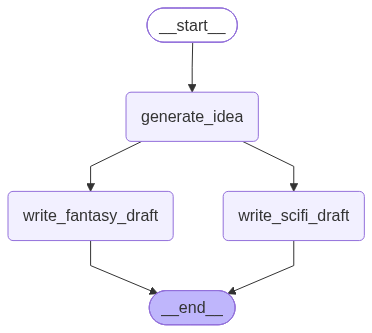

In [36]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
initial_state = {
    "topic": "a cybernetic cat discovering ancient magic deep inside an abandoned spacesuit on Mars",
}

result = graph.invoke(initial_state)
for i, draft in enumerate(result.get("drafts", []), 1):
  print(f"\n[Draft {i}]")
  print(draft)


## Command

In [38]:
from langchain_core.prompts import PromptTemplate
genre_prompt = PromptTemplate.from_template(
    "Classify this story idea as either 'sci-fi' or 'fantasy'. "
    "Reply with exactly one of those two words: {idea}"
)

In [39]:
from langgraph.types import Command

def classify_genre_node(state: StateWithGenre) -> Command[Literal["write_scifi_draft", "write_fantasy_draft"]]:
    chain = genre_prompt | llm
    response = chain.invoke({"idea": state["idea"]})
    genre = response.text.strip().lower()

    resolved_genre: Literal["sci-fi", "fantasy"] = "sci-fi"
    if "fantasy" in genre:
        resolved_genre = "fantasy"

    next_node = "write_scifi_draft" if resolved_genre == "sci-fi" else "write_fantasy_draft"

    print(f"\n[classify_genre] Classified idea as: '{resolved_genre}'")
    print(f"[classify_genre] Returning Command(update={{'genre': '{resolved_genre}'}}, goto='{next_node}')")

    return Command(
        update={"genre": resolved_genre},
        goto=next_node
    )


builder = StateGraph(State)
builder.add_node("generate_idea", generate_idea_node)
builder.add_node("classify_genre", classify_genre_node)
builder.add_node("write_scifi_draft", write_scifi_draft_node)
builder.add_node("write_fantasy_draft", write_fantasy_draft_node)
builder.add_edge(START, "generate_idea")
builder.add_edge("generate_idea", "classify_genre")
builder.add_edge("write_scifi_draft", END)
builder.add_edge("write_fantasy_draft", END)
graph = builder.compile()

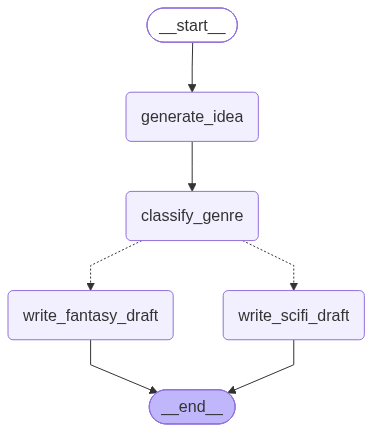

In [40]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
scifi_state = {"topic": "a cybernetic detective solving a mystery on Mars"}
result_scifi = graph.invoke(scifi_state)
print(f"\nFinal State - Genre: {result_scifi.get('genre')}")
print(result_scifi.get("draft"))


[classify_genre] Classified idea as: 'sci-fi'
[classify_genre] Returning Command(update={'genre': 'sci-fi'}, goto='write_scifi_draft')

Final State - Genre: None
Silas Vance stood amidst the choking, tropical dampness of the sealed Martian greenhouse, his cybernetic oculars whirring as they filtered out the physical room and dialed into the high-amplitude magnetic spectrum. Through the glowing, neon-indigo overlay of his HUD, the victim’s suffocated body faded into a thermal shadow, eclipsed by an impossible anomaly: a shimmering, ribbon-like trail of polarized iron-dust suspended in the pressurized air like a dormant nebula. To trace this phantom, Vance triggered a level-four neural overclock, grimacing as icy cerebral coolant flooded his spine to buffer the white-hot spike in his processing chips. Instantly, the chaotic electromagnetic noise of the dome resolved into a pristine, high-fidelity grid, revealing that the "dust-ghost" had hummed at a precise, phase-shifting frequency—vib

# Map-Reduce example

In [42]:
import operator
from typing import Annotated
from langchain_core.prompts import ChatPromptTemplate

class AgentState(TypedDict):
   video_uri: str
   chunks: int
   interval_secs: int
   summaries: Annotated[list, operator.add]
   final_summary: str

class _ChunkState(TypedDict):
   video_uri: str
   start_offset: int
   interval_secs: int

human_part = {"type": "text", "text": "Provide a summary of the video."}

reduce_prompt = ChatPromptTemplate.from_template(
    "Summarize the following chunk summaries into a cohesive overall video summary:\n\n{summaries}"
)

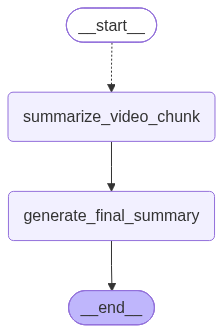

In [43]:
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langgraph.types import Send


def _merge_summaries(summaries: list[str], interval_secs: int) -> str:
   formatted_summaries = []
   for i, summary in enumerate(summaries):
       start = i * interval_secs
       end = (i + 1) * interval_secs
       formatted_summaries.append(f"[{start}s - {end}s]: {summary}")
   return "\n".join(formatted_summaries)

async def _summarize_video_chunk(state: _ChunkState):
   start_offset = state["start_offset"]
   interval_secs = state["interval_secs"]
   video_part = {
       "type": "media", "file_uri": state["video_uri"], "mime_type": "video/mp4",
       "video_metadata": {
           "start_offset": f"{start_offset*interval_secs}s",
           "end_offset": f"{(start_offset+1)*interval_secs}s"}
   }
   response = await llm.ainvoke(
       [HumanMessage(content=[human_part, video_part])]
   )
   return {"summaries": [response.content]}

async def _generate_final_summary(state: AgentState):
   summary = _merge_summaries(
       summaries=state["summaries"], interval_secs=state["interval_secs"])
   final_summary = await (reduce_prompt | llm | StrOutputParser()).ainvoke({"summaries": summary})
   return {"final_summary": final_summary}

def _map_summaries(state: AgentState):
   chunks = state["chunks"]
   payloads = [
       {
           "video_uri": state["video_uri"],
           "interval_secs": state["interval_secs"],
           "start_offset": i
       } for i in range(state["chunks"])
   ]
   return [Send("summarize_video_chunk", payload) for payload in payloads]

builder = StateGraph(AgentState)
builder.add_node("summarize_video_chunk", _summarize_video_chunk)
builder.add_node("generate_final_summary", _generate_final_summary)
builder.add_conditional_edges(START, _map_summaries, ["summarize_video_chunk"])
builder.add_edge("summarize_video_chunk", "generate_final_summary")
builder.add_edge("generate_final_summary", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [44]:
!gsutil cp gs://cloud-samples-data/generative-ai/video/google_sustainability.mp4 .

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://cloud-samples-data/generative-ai/video/google_sustainability.mp4...
- [1 files][ 33.8 MiB/ 33.8 MiB]                                                
Operation completed over 1 objects/33.8 MiB.                                     


In [45]:
from google import genai
import base64
import time

client = genai.Client(api_key=google_api_key)

myfile = client.files.upload(file="google_sustainability.mp4")

while not myfile.state or myfile.state.name != "ACTIVE":
    print("Processing video...")
    time.sleep(5)
    myfile = client.files.get(name=myfile.name)


Processing video...
Processing video...
Processing video...
Processing video...
Processing video...


In [46]:
print(myfile.uri)

https://generativelanguage.googleapis.com/v1beta/files/vu4bt3qihhg6


In [47]:
video_uri = "gs://cloud-samples-data/generative-ai/video/google_sustainability.mp4"
result = await graph.ainvoke(
    {"video_uri": myfile.uri, "chunks": 5, "interval_secs": 50},
    {"max_concurrency": 3}
)
print(f"Final Summary:\n{result.get('final_summary')}")

Final Summary:
Based on the provided video segments, here is a cohesive overall summary:

In this video, Google CEO Sundar Pichai highlights the company’s 25-year commitment to fighting climate change and leveraging technology to help others achieve their sustainability goals. 

Internally, Google is making significant progress toward operating entirely on 24/7 carbon-free energy. Key milestones include powering their Bay View campus in California with wind, solar, and geothermal energy, and tracking toward nearly 80% carbon-free energy in Belgium by 2024. Building on its history of prioritizing clean energy—including matching 100% of its energy use with renewables since 2017—Google currently runs two-thirds of its offices and data centers on carbon-free energy. The company's ultimate goal is to reach 100% carbon-free energy by 2030, supported by next-generation projects like its geothermal initiative in Nevada.

Pichai also discusses how Google is leveraging AI and data to empower ind